In [6]:
import os
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
final_dataset = pd.read_csv('final_dataset_onlyESG.csv')
encoded_cols = []
for cols in final_dataset.columns:
    match = re.match(r'[A-D][0-9]+\.+[0-9]*\.*', cols)
    if match:
        encoded_cols.append(match.group())
encoded_cols.append('Risk Rating')

final_dataset = pd.read_csv('final_dataset_onlyESG.csv', dtype={col: 'category' for col in encoded_cols})
final_dataset.rename(columns={'index': 'Company'}, inplace=True)

In [8]:
final_dataset.columns

Index(['Company', 'A1.1.', 'A1.2.', 'A2.1.', 'A2.2.', 'A2.3.', 'A2.4.',
       'A3.1.', 'A3.2.', 'A3.3.', 'A4.1.', 'B1.', 'B2.', 'B4.', 'B5.', 'B7.',
       'B8.', 'B9.', 'B10.', 'B11.', 'B12.', 'B13.', 'B14.', 'B15.', 'B16.',
       'B17.', 'B18.', 'B19.', 'B20.', 'B21.', 'B22.', 'B23.', 'B24.', 'C1.1.',
       'C1.2.', 'C1.3.', 'C1.4.', 'C1.5.', 'C1.6.', 'C1.7.', 'C1.8.', 'C1.9.',
       'C1.10.', 'C2.1.', 'C2.2.', 'C2.3.', 'C2.4.', 'C2.5.', 'D1.', 'D2.',
       'B25.', 'ESG Score', 'Risk Rating', 'Industry Ranking',
       'Global Ranking'],
      dtype='object')

In [9]:
for cols in final_dataset.columns:
    if cols == 'Company':
        continue
    if cols not in encoded_cols:
        final_dataset[cols] = pd.to_numeric(final_dataset[cols].replace({'\.': '', ',': ''}, regex=True), errors='coerce')

# Function to convert all categorical columns to ordered categorical
def convert_to_ordered_categorical(df):
    # Iterate through each column in the dataframe
    for column in df.select_dtypes(include=['category']).columns:
        # Convert categorical columns to ordered categorical
        df[column] = df[column].cat.as_ordered()
    return df

final_dataset = convert_to_ordered_categorical(final_dataset)

Preprocessing the data and applying StandardScaler...
Training and evaluating models with 5-fold cross-validation...
Training and tuning Linear Regression with 5-fold cross-validation...


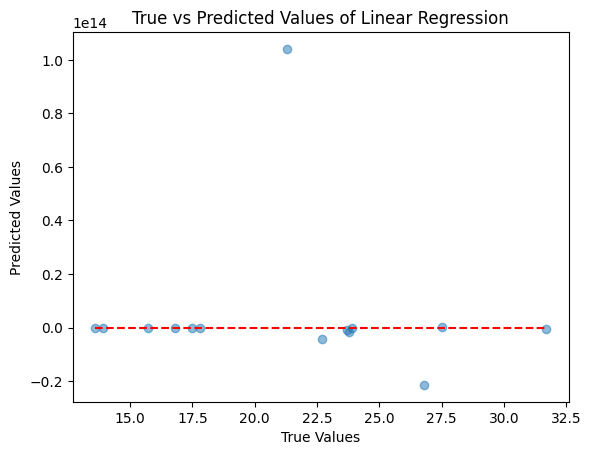

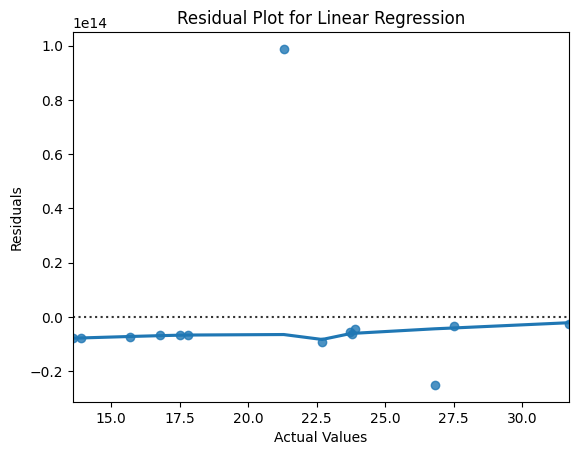

Training and tuning Lasso Regression with 5-fold cross-validation...
Best params for Lasso Regression: {'alpha': 0.1}


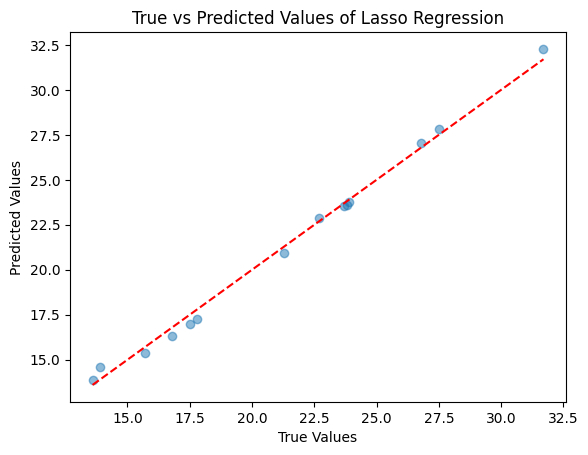

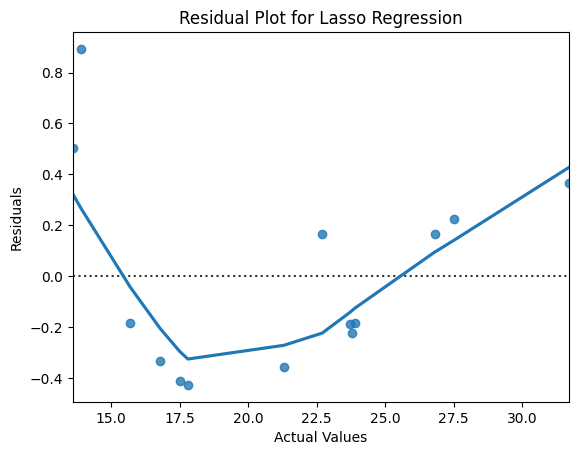

Training and tuning Ridge Regression with 5-fold cross-validation...
Best params for Ridge Regression: {'alpha': 1.0}


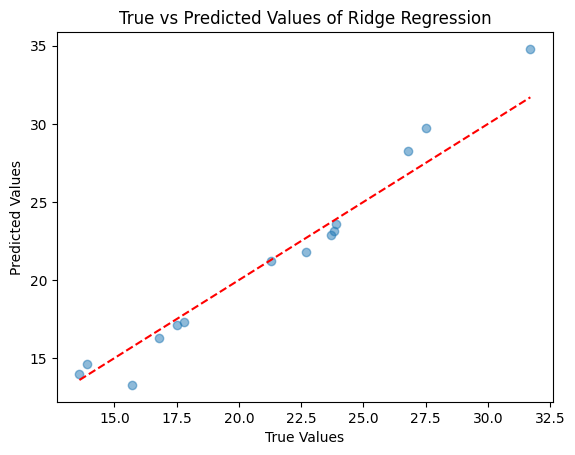

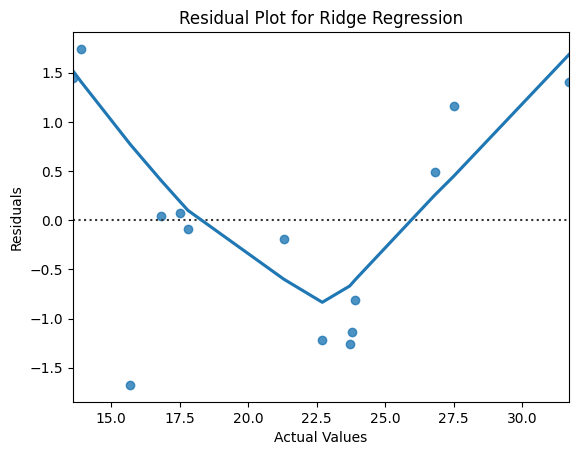

Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


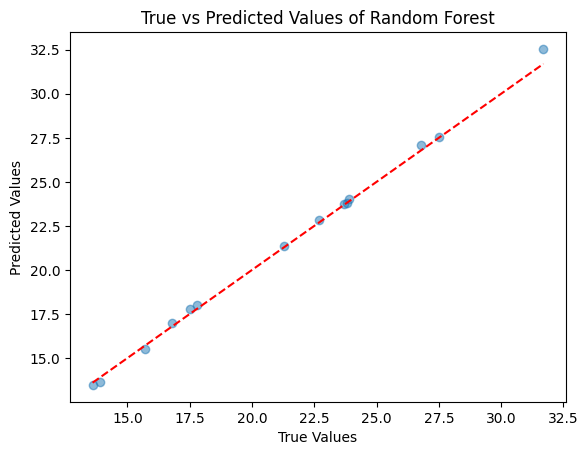

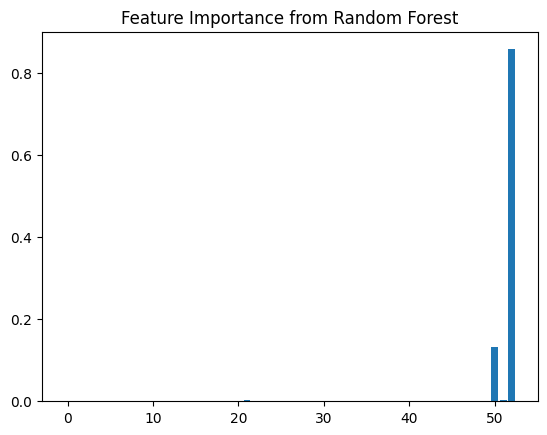

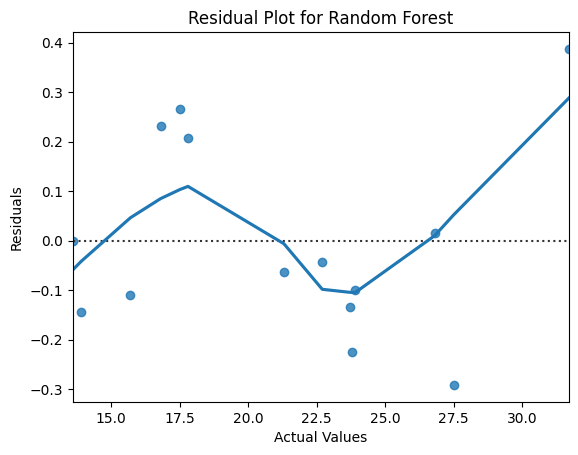

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


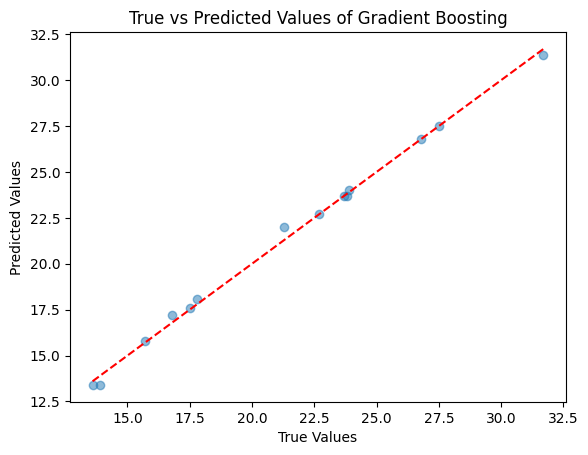

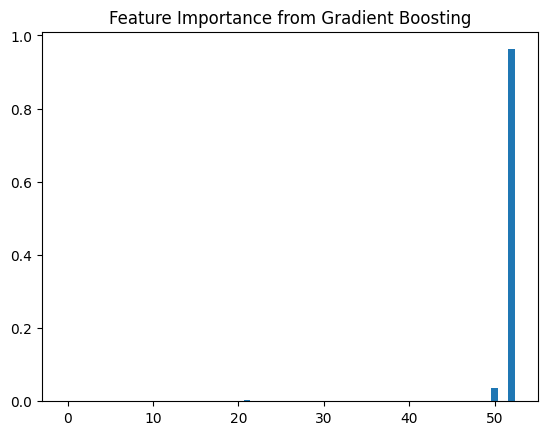

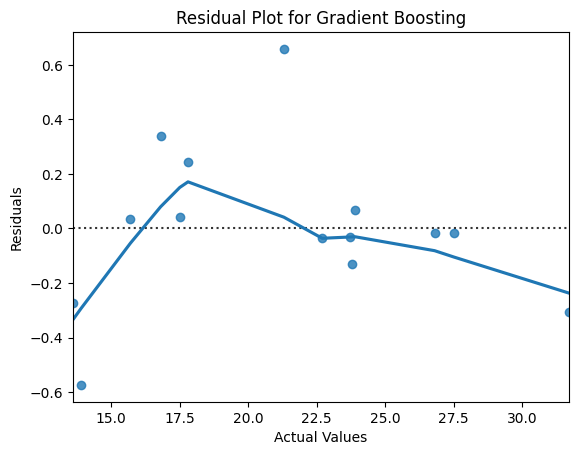

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


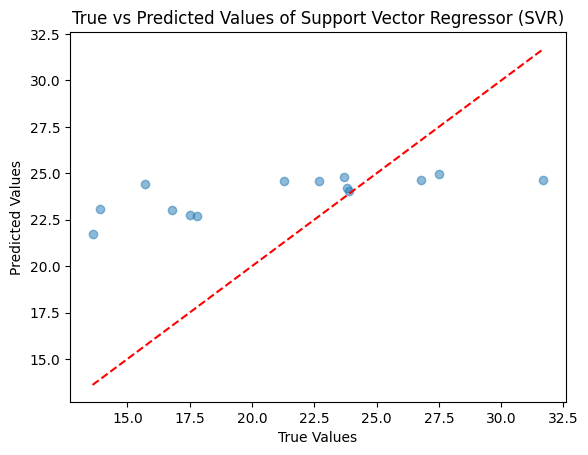

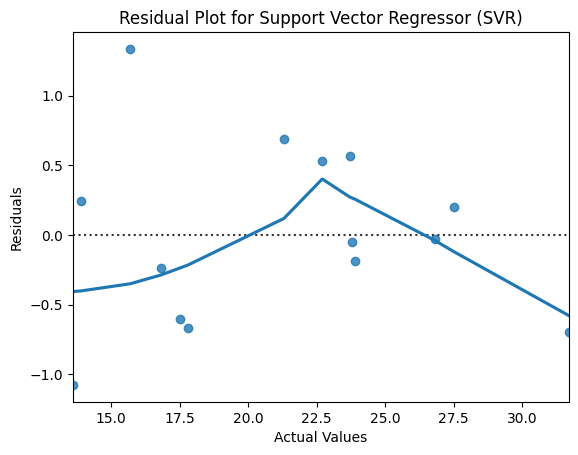

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 3, 'weights': 'distance'}


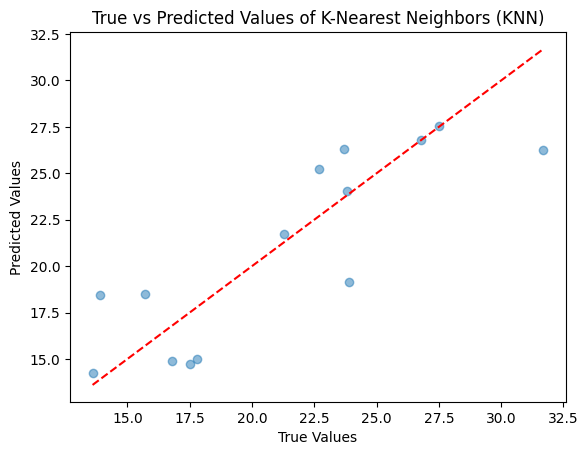

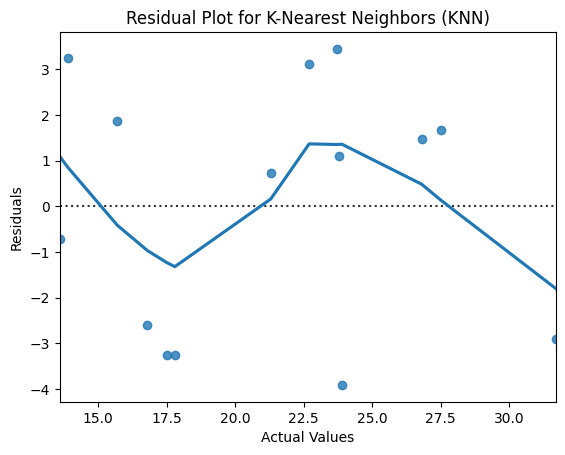


Model Evaluation Results with Cross-Validation:
                            Model    Avg CV MSE      Test MSE      Test MAE  \
0               Linear Regression  48643.035952  8.085548e+26  9.521714e+12   
1                Lasso Regression      0.424822  1.621283e-01  3.666055e-01   
2                Ridge Regression      0.905462  1.837670e+00  1.029494e+00   
3                   Random Forest      0.546314  8.020907e-02  2.010714e-01   
4               Gradient Boosting      0.371946  8.320696e-02  2.006107e-01   
5  Support Vector Regressor (SVR)     45.066743  2.810120e+01  4.356139e+00   
6       K-Nearest Neighbors (KNN)     21.408957  8.136944e+00  2.255276e+00   

        Test R²  
0 -2.904223e+25  
1  9.941766e-01  
2  9.339933e-01  
3  9.971190e-01  
4  9.970113e-01  
5 -9.357983e-03  
6  7.077317e-01  


In [10]:
# Step 1: Preprocess Data (without PCA)
def preprocess_data(X):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso Regression": Lasso(),
        "Ridge Regression": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Lasso Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Ridge Regression": {
            "alpha": [0.01, 0.1, 1.0, 10]
        },
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Plot feature importance if available
        try:
            feature_importances = best_model.feature_importances_
            plt.bar(range(len(feature_importances)), feature_importances)
            plt.title(f"Feature Importance from {name}")
            plt.show()
        except AttributeError:
            pass

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    print("Preprocessing the data and applying StandardScaler...")
    X_scaled = preprocess_data(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()

Preprocessing the data and applying StandardScaler...


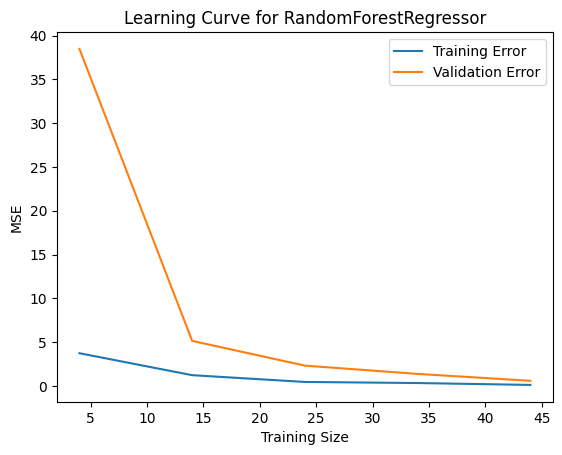

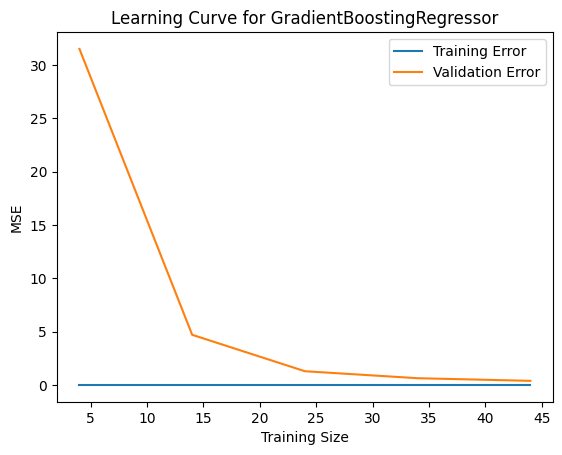

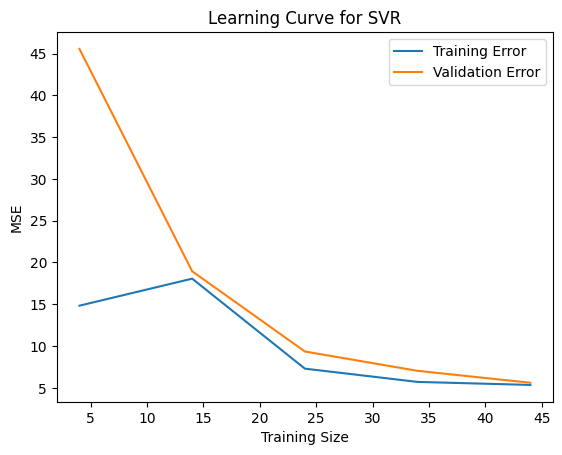

/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
  File "/opt/miniconda3/envs/dsmart/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 89, in _cached_call
    result, _ = _get_response_values(
  File "/opt/miniconda3/envs/dsmart/lib/python3.10/site-

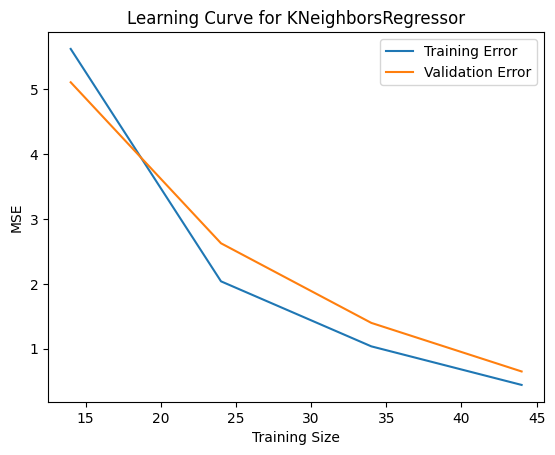

In [11]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    
    train_mean = -train_scores.mean(axis=1)
    test_mean = -test_scores.mean(axis=1)
    
    plt.plot(train_sizes, train_mean, label='Training Error')
    plt.plot(train_sizes, test_mean, label='Validation Error')
    plt.title(f"Learning Curve for {model.__class__.__name__}")
    plt.xlabel("Training Size")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()


X = final_dataset.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
y = final_dataset['ESG Score']

print("Preprocessing the data and applying StandardScaler...")
#X_scaled = preprocess_data(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot learning curves for the best models
plot_learning_curve(RandomForestRegressor(), X_train, y_train)
plot_learning_curve(GradientBoostingRegressor(), X_train, y_train)
plot_learning_curve(SVR(), X_train, y_train)
plot_learning_curve(KNeighborsRegressor(), X_train, y_train)

<H1> Without Scaling

Training and evaluating models with 5-fold cross-validation...
Training and tuning Random Forest with 5-fold cross-validation...
Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


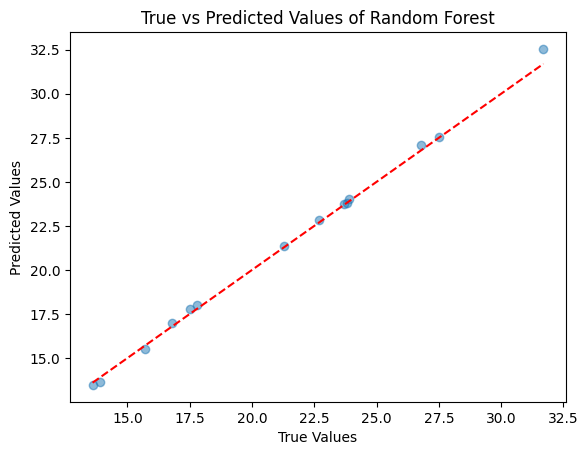

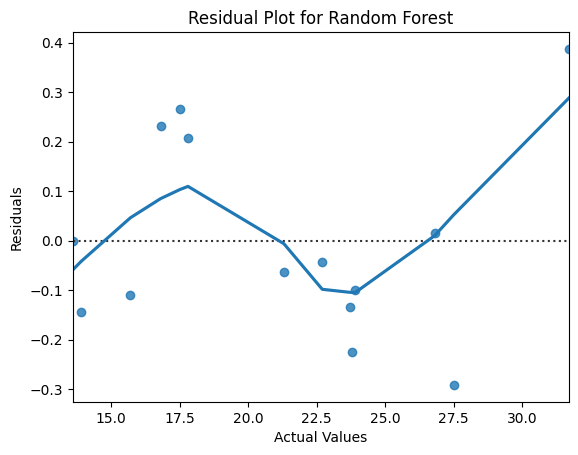

Training and tuning Gradient Boosting with 5-fold cross-validation...
Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


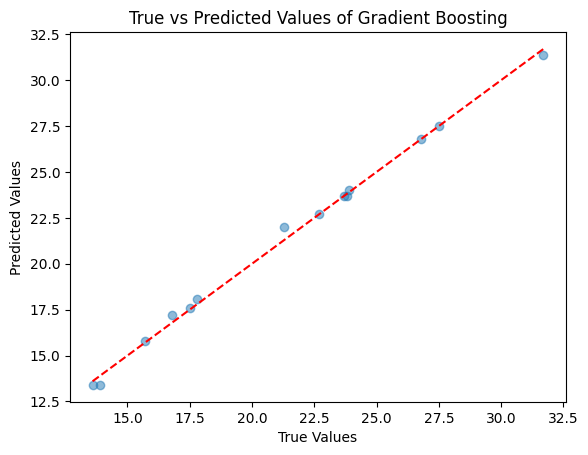

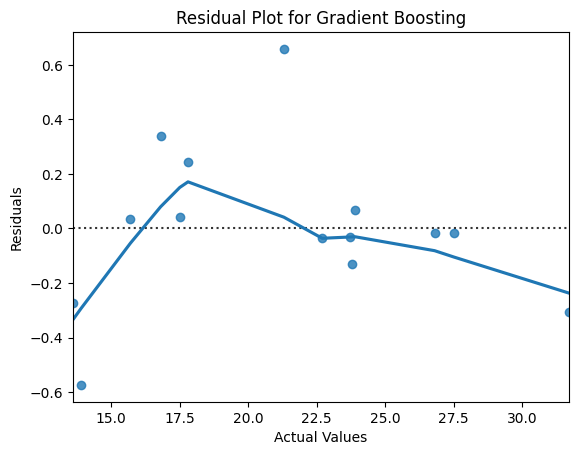

Training and tuning Support Vector Regressor (SVR) with 5-fold cross-validation...


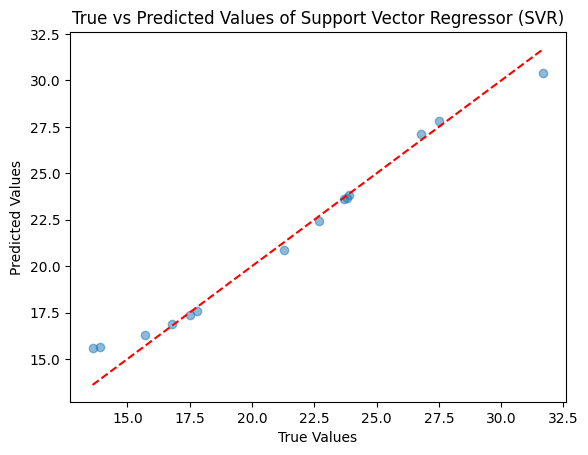

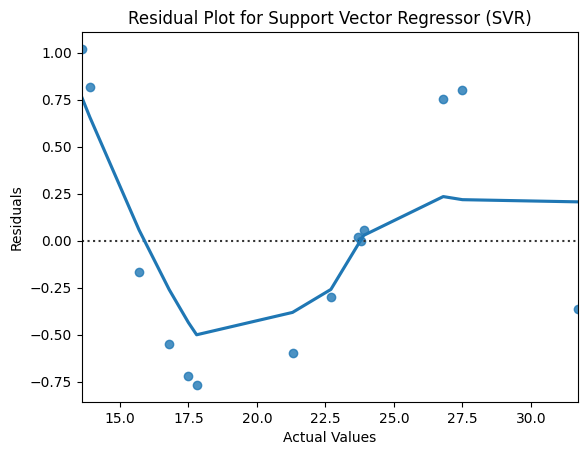

Training and tuning K-Nearest Neighbors (KNN) with 5-fold cross-validation...
Best params for K-Nearest Neighbors (KNN): {'n_neighbors': 3, 'weights': 'distance'}


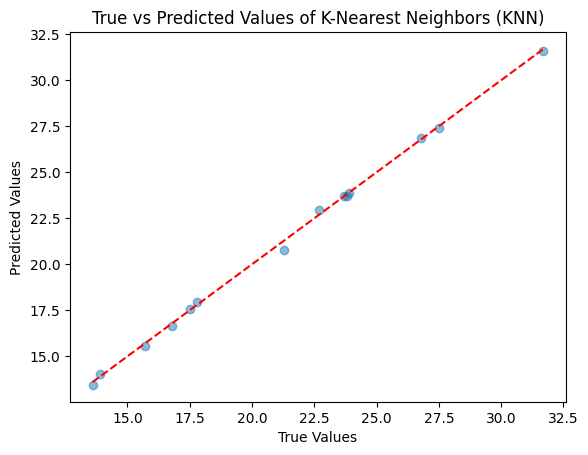

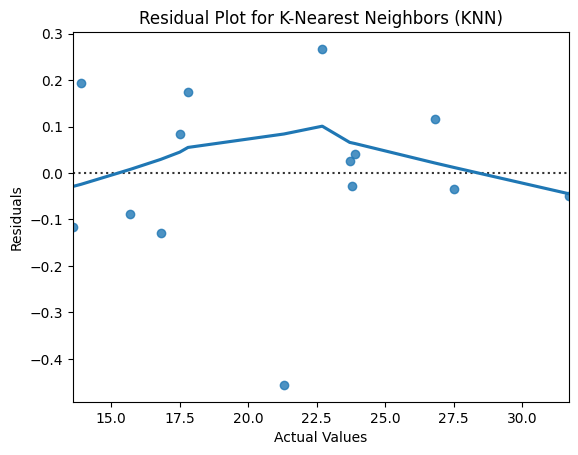


Model Evaluation Results with Cross-Validation:
                            Model  Avg CV MSE  Avg CV R²  Test MSE  Test MAE  \
0                   Random Forest    0.546314   0.989976  0.080209  0.201071   
1               Gradient Boosting    0.371946   0.993692  0.083207  0.200611   
2  Support Vector Regressor (SVR)    5.518367   0.904645  0.689616  0.550786   
3       K-Nearest Neighbors (KNN)    0.334830   0.994039  0.031126  0.131291   

    Test R²  
0  0.997119  
1  0.997011  
2  0.975230  
3  0.998882  


In [12]:
# Step 1: Preprocess Data (without PCA)
def preprocess_data(X):
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled

# Step 2: Train, Evaluate, and Tune Models with Cross-Validation
def evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=5):
    # Define regression models to test
    models = {
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Support Vector Regressor (SVR)": SVR(),
        "K-Nearest Neighbors (KNN)": KNeighborsRegressor()
    }
    
    # Hyperparameter grid for tuning
    param_grids = {
        "Random Forest": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        },
        "Gradient Boosting": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5, 10]
        },
        "SVR": {
            "C": [1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        },
        "K-Nearest Neighbors (KNN)": {
            "n_neighbors": [3, 5, 10],
            "weights": ["uniform", "distance"]
        }
    }
    
    results = []

    for name, model in models.items():
        print(f"Training and tuning {name} with {cv_folds}-fold cross-validation...")

        # Perform grid search if hyperparameters are provided
        if name in param_grids:
            grid_search = GridSearchCV(
                estimator=model, 
                param_grid=param_grids[name], 
                cv=cv_folds, 
                scoring='neg_mean_squared_error'
            )
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"Best params for {name}: {grid_search.best_params_}")
        else:
            best_model = model
            best_model.fit(X_train, y_train)

        # Cross-validation scores
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
        avg_cv_mse = -np.mean(cv_scores)  # Convert to positive MSE

        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_folds, scoring='r2')
        avg_cv_r2 = np.mean(cv_scores)

        # Make predictions on test set
        y_pred = best_model.predict(X_test)

        # Plot true vs predicted values
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal fit line
        plt.xlabel("True Values")
        plt.ylabel("Predicted Values")
        plt.title(f"True vs Predicted Values of {name}")
        plt.show()

        # Calculate test set metrics
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Residual plot
        sns.residplot(x=y_test, y=y_pred, lowess=True)
        plt.title(f"Residual Plot for {name}")
        plt.xlabel("Actual Values")
        plt.ylabel("Residuals")
        plt.show()

        # Store results
        results.append({
            "Model": name,
            "Avg CV MSE": avg_cv_mse,
            "Avg CV R²": avg_cv_r2,
            "Test MSE": mse,
            "Test MAE": mae,
            "Test R²": r2
        })

    return pd.DataFrame(results)

# Main Script
def main():
    # Load the dataset (modify this if you have multiple sheets)
    df = final_dataset

    # Separate features (X) and target (y)
    X = df.drop(columns=["ESG Score", 'Company'])  # Exclude 'Hisse' and target column
    y = df['ESG Score']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Evaluate and tune models with cross-validation
    cv_folds = 5  # Number of folds for cross-validation
    print(f"Training and evaluating models with {cv_folds}-fold cross-validation...")
    results = evaluate_and_tune_models_with_cv(X_train, y_train, X_test, y_test, cv_folds=cv_folds)

    # Display results
    print("\nModel Evaluation Results with Cross-Validation:")
    print(results)

if __name__ == "__main__":
    main()